# Homework 1 - Unsupervised Learning

Welcome to Homework 1! In this assignment, you will get to implement K-Means and Gaussian Mixture Models on MNIST data.

## Due Date: Sunday, April 12, 11:59 PM

This assignment is due on **Sunday, April 12, at 11:59 PM**. You must submit your work to LearnHub by this deadline.

### Submission Tips:
- **Plan ahead**: We strongly encourage you to submit your work several hours before the deadline. This will give you ample time to address any submission issues.
- **Reach out for help early**: If you encounter difficulties, contact course staff well before the deadline. While we are happy to assist with submission issues, we cannot guarantee responses to last-minute requests.


---

## Assignment Overview

In this assignment you will implement K-Means and Gaussian Mixture Models on the MNIST data from scratch. You will complete all the TODOs in the notebook, which include both coding and written response questions. Some tasks are open-ended, which allows you to explore and experiment with different approaches.

### Key Learning Objectives:
1. Implementing K-Means clustering algorithm.
2. Implementing Gaussian Mixture Models.
2. Clustering data using K-Means and GMM and evaluating their performance.

---

### Instructions:
1. Carefully read each question and its requirements.
2. Complete all TODOs in the notebook. You may add extra lines of code if needed to implement your solution.
3. For manual questions, provide clear and concise written responses.
4. Test your code thoroughly to ensure it meets the requirements.

Good luck!

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal

In [75]:
# Download MNIST dataset
# The first time you run this, it may take a while to download the dataset. Subsequent runs will be faster.
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.values / 255.0
y = mnist.target.values.astype(int)

print('MNIST dataset loaded.')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Image dtype: {X.dtype}, Label dtype: {y.dtype}')

MNIST dataset loaded.
X shape: (70000, 784), y shape: (70000,)
Image dtype: float64, Label dtype: int64


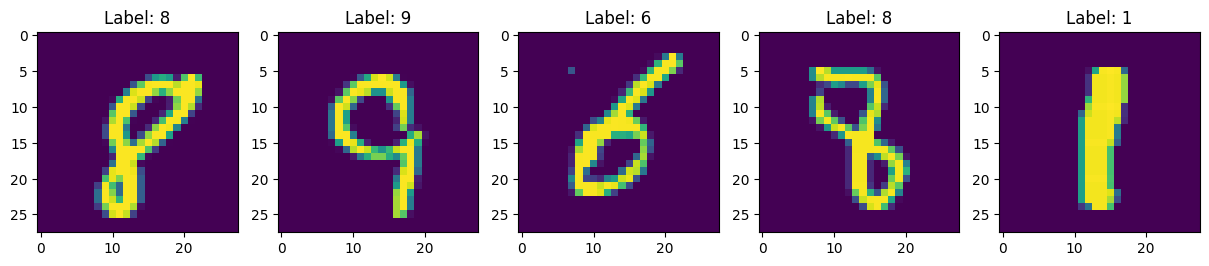

In [76]:
# TODO: Visualize the first 5 images in the dataset, along with their labels.

def visualize_images(images, labels, indices):
  plt.figure(figsize=(15, 5))

  for i, idx in enumerate(indices):
    plt.subplot(1, len(indices), i + 1)

    plt.imshow(images[idx].reshape(28, 28))
    plt.title(f"Label: {labels[idx]}")

  plt.show()

indices = np.random.choice(len(X), 5, replace=False)
visualize_images(X, y, indices)

### Problem 1
**Task:** Implement the `kmeans` function. This function takes the following inputs:
- `x`: a numpy array of shape `(N, D)`, where `N` is the number of samples and `D` is the number of features.
- `k`: the number of clusters to form.
- `max_iters`: the maximum number of iterations for the algorithm.

The function should cluster the data into `k` clusters using the K-Means algorithm. The algorithm should terminate when either:
1. The cluster assignments no longer change between iterations, or
2. The number of iterations reaches `max_iters`.


**Important**: You must implement K-Means yourself from scratch. Using `KMeans` from `sklearn` or any other library is NOT ALLOWED.

In [77]:
def k_means(x, k, max_iters=100):
    '''
    x: (N, D) data points
    k: number of clusters
    max_iters: maximum number of iterations
    Returns:
        centroids: (k, D) cluster centroids
        labels: (N,) cluster assignments for each data point
        shifts: (num_iters,) centroid shifts at each iteration
    '''
    #TODO: Implement K-Means clustering algorithm
    # your function should return centroids, labels, and shifts
    # shifts should record the change in centroids at each iteration
    # the change can should be measured as the frobenius distance between the old and new centroids, i.e., ||C_new - C_old||_F
    # Hint: You can use np.linalg.norm to compute distances

    centers = x[np.random.choice(x.shape[0], k, replace=False)];
    assignments = []
    shifts = []

    for _ in range(max_iters):
      dist = np.linalg.norm(x[:, np.newaxis] - centers, axis=2)

      assignments = np.argmin(dist, axis=1)

      new_centers = np.array([x[assignments == i].mean(axis=0) for i in range(k)])

      shifts.append(np.linalg.norm(new_centers - centers))

      if np.array_equal(centers, new_centers):
        break

      centers = new_centers

    return centers, assignments, shifts


In [78]:
np.random.seed(42)
kmeans_centroids, kmeans_labels, kmeans_shifts = k_means(X, 10)
print('Done with k_means_clustering.')


Done with k_means_clustering.


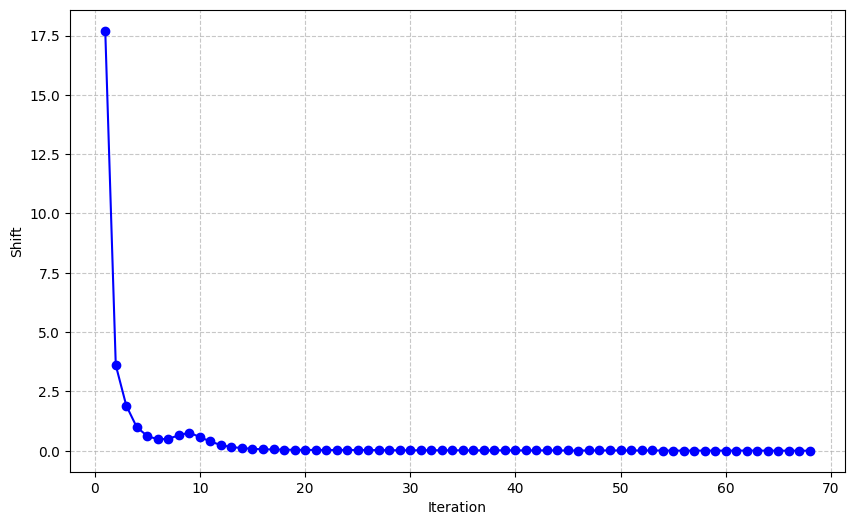

In [79]:
# TODO: plot the centroid shifts over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(kmeans_shifts) + 1), kmeans_shifts, marker='o', linestyle='-', color='b')

plt.xlabel('Iteration')
plt.ylabel('Shift')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The labels produced by K-Means are arbitrary and do not necessarily correspond to the ground-truth classes. For example, cluster 0 might predominantly contain samples of digit 4.

To interpret the clusters in terms of actual labels, we must determine which true class is most common within each cluster. To do this, we construct a confusion matrix for our clustering results. The matrix `kmeans_confusion_matrix` is a `10×10` array where each entry `kmeans_confusion_matrix[i, j]` indicates how many samples assigned to cluster `i` actually belong to class `j`.

In [80]:
#TODO: Create confusion matrix
def confusion_matrix(y_true, y_pred):
    num_classes = len(np.unique(y_true))
    return np.array([[np.sum((y_pred == i) & (y_true == j)) for j in range(num_classes)] for i in range(num_classes)])

kmeans_confusion_matrix = confusion_matrix(y, kmeans_labels)
print(kmeans_confusion_matrix)

[[ 569   16  166 1402    8 1905  118    6 3536   54]
 [  13   37   48  209 2536  490    9  484  402 3307]
 [ 265   14  430 4555    0 2024   29    6 1480   91]
 [   4    3   68   34    6   11    0 3840   14  165]
 [  88   11   77   60 1901  787    9 2020  434 1886]
 [5471    0   80   36    2   69   84   10   35   34]
 [ 280   17  160   68  118  168 5111    4   54   10]
 [  48   69 4892  277   16   22   50   48   61    4]
 [  21 7709  833  458  174  705  447  459  679  180]
 [ 144    1  236   42 2063  132 1019  416  130 1227]]


Next, we will normalize the confusion matrix. Specifically, `normalized_kmeans_confusion_matrix[i, j]` will represent the percentage of samples in cluster `i` that belong to digit `j`. (Note that the sum of each row should be 100)

In [81]:
# TODO: Normalize confusion matrix
def norm_cm(cm):
  r_sum = cm.sum(axis=1, keepdims=True)
  r_sum[r_sum == 0] = 1 # for zero division error
  return cm / r_sum*100

kmeans_normalized_confusion_matrix = norm_cm(kmeans_confusion_matrix)

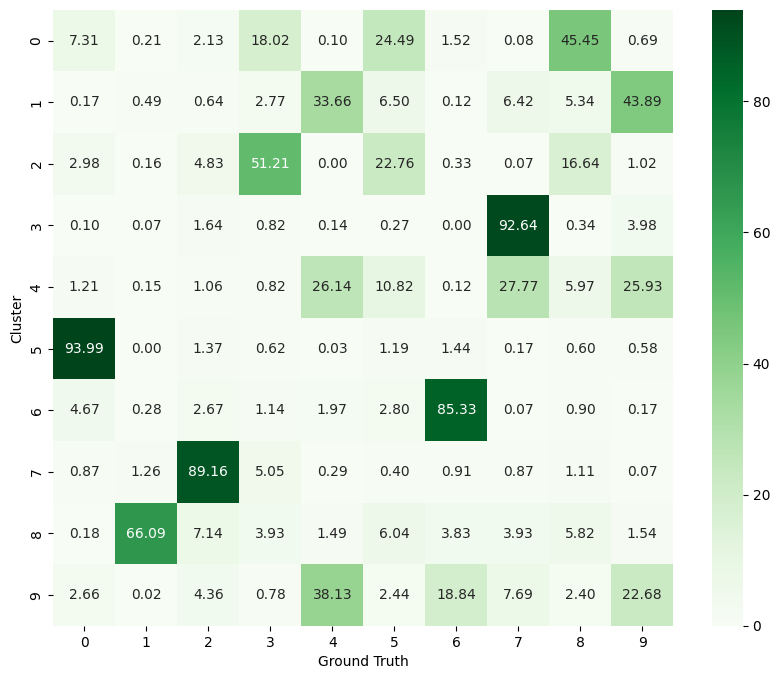

In [82]:
# TODO: plot the normalized confusion matrix as a heatmap
# You might find seaborn.heatmap useful for this. You can install it as "pip install seaborn" if you don't have it already.

plt.figure(figsize=(10, 8))
sns.heatmap(kmeans_normalized_confusion_matrix, annot=True, fmt='.2f', cmap='Greens')
plt.xlabel('Ground Truth')
plt.ylabel('Cluster')
plt.show()

Next, we will use the normalized confusion matrix to map each cluster to its most likely digit class. After running the next cell, `kmeans_assignments` will be an array of length 10, where `kmeans_assignments[i]` stores the digit label that cluster `i` is assigned to.

In [83]:
# TODO
kmeans_assignments = np.argmax(kmeans_normalized_confusion_matrix, axis=1)

for i in range(10):
    print(f'Cluster {i} is assigned to digit {kmeans_assignments[i]}')

Cluster 0 is assigned to digit 8
Cluster 1 is assigned to digit 9
Cluster 2 is assigned to digit 3
Cluster 3 is assigned to digit 7
Cluster 4 is assigned to digit 7
Cluster 5 is assigned to digit 0
Cluster 6 is assigned to digit 6
Cluster 7 is assigned to digit 2
Cluster 8 is assigned to digit 1
Cluster 9 is assigned to digit 4


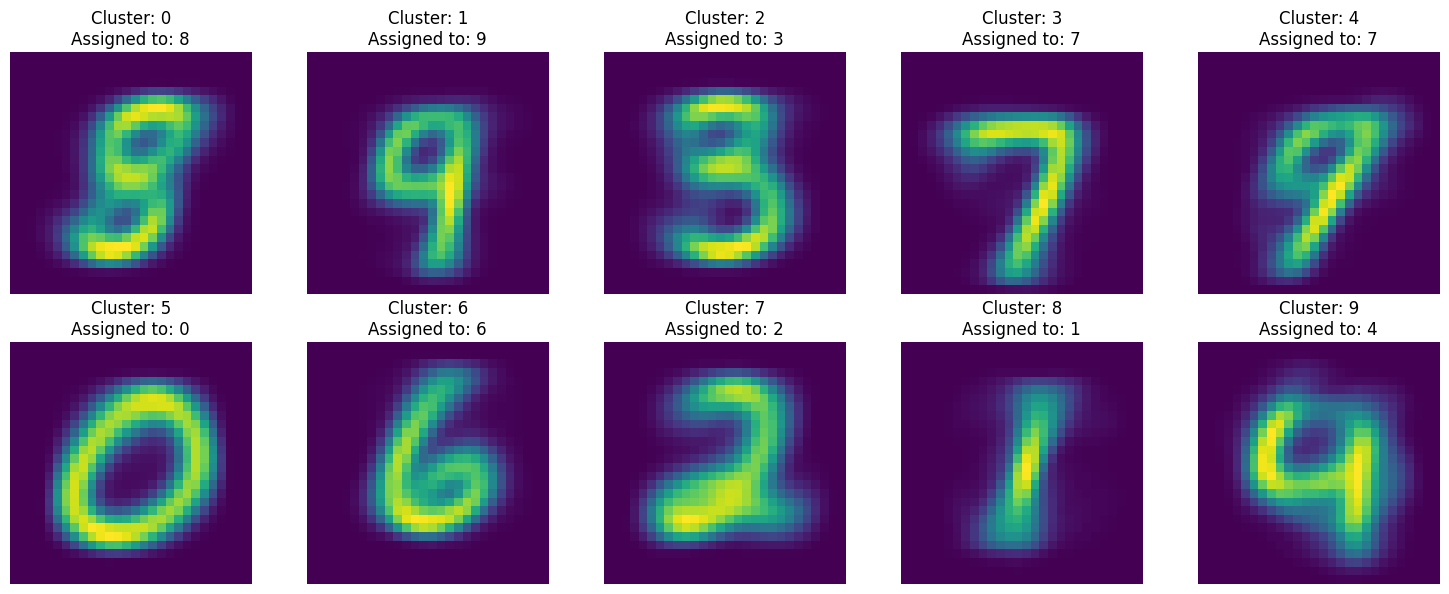

In [84]:
# TODO: visualize the centroids along with their mapped labels

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    centroid_image = kmeans_centroids[i].reshape(28, 28)
    plt.imshow(centroid_image)

    assigned_digit = kmeans_assignments[i]
    plt.title(f"Cluster: {i}\nAssigned to: {assigned_digit}")

    plt.axis('off')

plt.tight_layout()
plt.show()

Analyze the results.
- Did each cluster map to a distinct class label?
- Are there any classes that no cluster was mapped to?
- Are there any classes that multiple clusters were mapped to?

Discuss:
- Yes, no cluster has more than one label.
- Yes, we don't have label 5
- No, we have 2 label 7

\# TODO

Now we will use `kmeans_assignments` to map each image to its predicted digit label. After running the next cell, `kmeans_cluster_labels` will be an array of size 70000 where `kmeans_cluster_labels[i]` will contain the digit assigned to image `i` based on the K-Means clustering results.

In [85]:
# TODO
kmeans_cluster_labels = np.array([kmeans_assignments[label] for label in kmeans_labels])

Finally, will evaluate the accuracy of the k-means clustering on the data:

In [86]:
# TODO: evaluate clustering accuracy
accuracy = np.sum(kmeans_cluster_labels == y) / len(y)
print(f'K-Means Clustering Accuracy: {accuracy * 100:.2f}%')

K-Means Clustering Accuracy: 60.72%


### Problem 2
In this problem, we will explore the implementation of Gaussian Mixture Models using the Expectation–Maximization algorithm.

Because applying a GMM directly to 784-dimensional data would be computationally expensive, we will first reduce the dimensionality of our dataset to 30 using PCA. You can read more about PCA here: https://en.wikipedia.org/wiki/Principal_component_analysis

For the purposes of this assignment, you only need to know that PCA takes each 784-dimensional data point and projects it into a 30-dimensional space, allowing our algorithm to run more efficiently.

In [87]:
pca = PCA(n_components=30, random_state=0)
X_pca = pca.fit_transform(X)

**Task:** Implement the `gmm` function. This function takes the following inputs:
- `x`: a numpy array of shape `(N, D)`, where `N` is the number of samples and `D` is the number of features.
- `k`: the number of Gaussian components.
- `max_iters`: the maximum number of iterations for the algorithm.

The function should fit a GMM to the the data using the EM algorithm. The function will terminate after `max_iters` iterations.


**Important**: You must implement GMM yourself from scratch. Using `GaussianMixture` from `sklearn` or any other library is NOT ALLOWED.

In [88]:
def gmm(x, k, max_iters=100):
      '''
      x: (N, D) data points
      k: number of clusters
      max_iters: maximum number of iterations
      Returns:
      mu: (k, D) cluster centroids
      Sigma: (k, D, D) cluster covariances
      p: (k,) mixture weights
      responsibilities: (N, k) final responsibilities
      '''
      #TODO: Fit a Gaussian Mixture Model to data x using the EM algorithm
      #This function should return means, covariances, mixture_weights, and final responsibilities
      mu = x[np.random.choice(x.shape[0], k, replace=False)]
      Sigma = np.array([np.eye(x.shape[1]) for _ in range(k)])
      p = np.ones(k) / k
      responsibilities = np.zeros((x.shape[0], k))

      for _ in range(max_iters):
        # E-step
        for i in range(k):
          normal = multivariate_normal(mean=mu[i], cov=Sigma[i])
          responsibilities[:, i] = p[i] * normal.pdf(x)

        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        for i in range(k):
          p[i] = np.mean(responsibilities[:, i])
          mu[i] = 1/(p[i]*x.shape[0]) * responsibilities[:, i] @ x
          Sigma[i] = 1/(p[i]*x.shape[0]) * responsibilities[:, i] * (x-mu[i]).T @ (x-mu[i])

      return mu, Sigma, p, responsibilities

In [89]:
np.random.seed(42)
gmm_mu, gmm_Sigma, gmm_p, gmm_p_z_given_x = gmm(X_pca,  k=10,  max_iters=50)

In [90]:
#TODO: compute GMM cluster labels. i.e, gmm_labels[i] should be the cluster label for data point i
gmm_labels = np.array([np.argmax(gmm_p_z_given_x[i, :]) for i in range(X_pca.shape[0])])

The labels produced by GMM are arbitrary and do not necessarily correspond to the ground-truth classes. For example, cluster 0 might predominantly contain samples of digit 4.

To interpret the clusters in terms of actual labels, we must determine which true class is most common within each cluster. To do this, we construct a confusion matrix for our clustering results. The matrix `gmm_confusion_matrix` is a `10×10` array where each entry `gmm_confusion_matrix[i, j]` indicates how many samples assigned to cluster `i` actually belong to class `j`.

In [91]:
#TODO: Create confusion matrix
gmm_confusion_matrix = confusion_matrix(y, gmm_labels)
print(gmm_confusion_matrix)

[[  49  634   74 1504   29  973  108   66 4752  113]
 [   0   13    0    8 1443    8    0  334    8 3563]
 [ 378   16  279 5354   70 3950  372   62 1189  193]
 [   1    1    5    4    0    0    0 4526    0   14]
 [ 122  704   62  108 1702 1322   60  656  773 1088]
 [6331    0   16    2    4    4   10    3    2    7]
 [   2    3   10    0   12   11 6299    0    0    0]
 [  17   82 6475   79   23    2    4  218   46   18]
 [   0 6420    0    0    1    0    1    1    4    1]
 [   3    4   69   82 3540   43   22 1427   51 1961]]


Next, we will normalize the confusion matrix. Specifically, `normalized_gmm_confusion_matrix[i, j]` will represent the percentage of samples in cluster `i` that belong to digit `j`. (Note that the sum of each row should be 100)

In [92]:
# TODO: normalize confusion matrix
normalized_gmm_confusion_matrix = norm_cm(gmm_confusion_matrix)

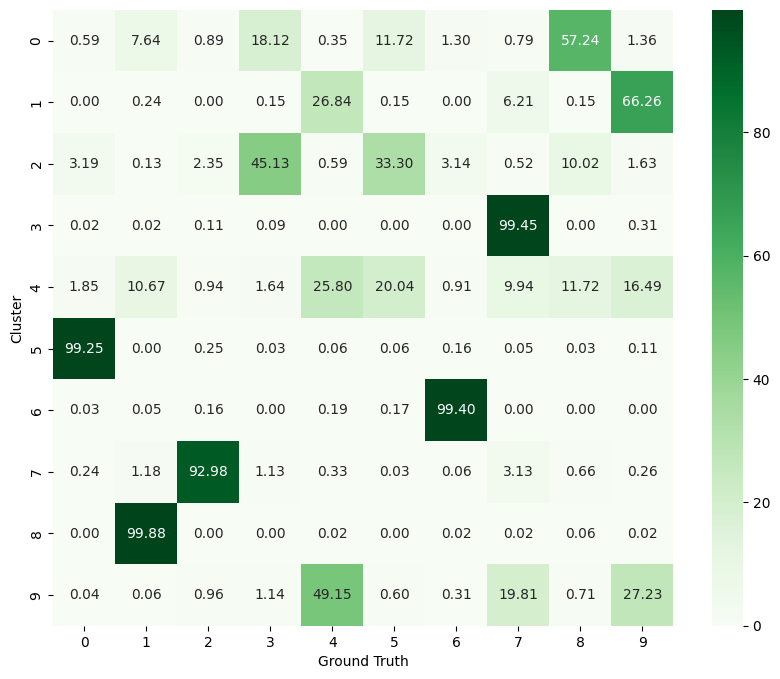

In [93]:
# plot the normalized confusion matrix as a heatmap
# You might find seaborn.heatmap useful for this. You can install it as "pip install seaborn" if you don't have it already.
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_gmm_confusion_matrix, annot=True, fmt='.2f', cmap='Greens')
plt.xlabel('Ground Truth')
plt.ylabel('Cluster')
plt.show()

Next, we will use the normalized confusion matrix to map each cluster to its most likely digit class. After running the next cell, `gmm_assignments` will be an array of length 10, where `gmm_assignments[i]` stores the digit label that cluster `i` is assigned to.

In [94]:
# TODO
gmm_assignments = np.argmax(normalized_gmm_confusion_matrix, axis=1)
for i in range(10):
    print(f'Cluster {i} is assigned to digit {gmm_assignments[i]}')

Cluster 0 is assigned to digit 8
Cluster 1 is assigned to digit 9
Cluster 2 is assigned to digit 3
Cluster 3 is assigned to digit 7
Cluster 4 is assigned to digit 4
Cluster 5 is assigned to digit 0
Cluster 6 is assigned to digit 6
Cluster 7 is assigned to digit 2
Cluster 8 is assigned to digit 1
Cluster 9 is assigned to digit 4


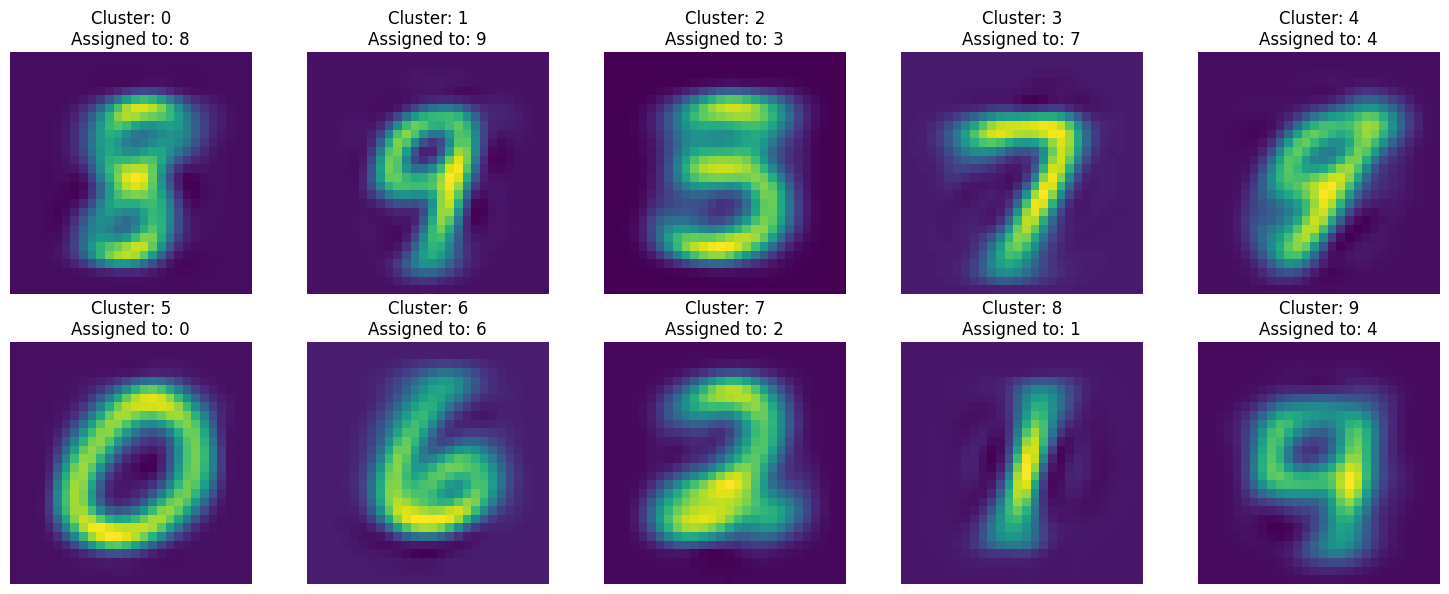

In [95]:
# TODO: visualize the gaussian means along with their mapped labels
plt.figure(figsize=(15, 6))

mu_original = pca.inverse_transform(gmm_mu)

for i in range(10):
    plt.subplot(2, 5, i + 1)

    centroid_image = mu_original[i].reshape(28, 28)
    plt.imshow(centroid_image)

    assigned_digit = gmm_assignments[i]
    plt.title(f"Cluster: {i}\nAssigned to: {assigned_digit}")

    plt.axis('off')

plt.tight_layout()
plt.show()

Analyze the results.
- Did each cluster map to a distinct class label?
- Are there any classes that no cluster was mapped to?
- Are there any classes that multiple clusters were mapped to?

Discuss:
- Yes, no cluster has more than one label.
- Yes, we don't have label 5
- No, we have 2 label 4

\# TODO

Now we will use `gmm_assignments` to map each image to its predicted digit label. After running the next cell, `gmm_cluster_labels` will be an array of size 70000 where `gmm_cluster_labels[i]` will contain the digit assigned to image `i` based on the GMM clustering results.

In [96]:
# TODO
gmm_cluster_labels = np.array([gmm_assignments[i] for i in gmm_labels])

Finally, will evaluate the accuracy of the GMM clustering on the data:

In [97]:
# TODO: evaluate clustering accuracy
accuracy = np.sum(gmm_cluster_labels == y) / len(y)
print(f'GMM Clustering Accuracy: {accuracy * 100:.2f}%')

GMM Clustering Accuracy: 69.95%
